In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("thyroid_dataset.csv")

In [6]:
df.shape

(6916, 22)

In [7]:
df.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

In [9]:
x = df.drop("Outlier_label",axis = 1)
y = df["Outlier_label"]

In [10]:
scaler = StandardScaler()

In [11]:
x_scaled = scaler.fit_transform(x)

In [12]:
from sklearn.ensemble import IsolationForest

In [16]:
fo = IsolationForest(
    n_estimators = 200,
    contamination = "auto",
    random_state = 42 
)

In [17]:
labels = fo.fit_predict(x_scaled)

In [27]:
labels

array([ 1,  1, -1, ...,  1,  1,  1])

In [18]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(
    n_components = 2,
)

In [22]:
x_pca = pca.fit_transform(x_scaled)

Text(0.5, 1.0, 'pc1 vs pc2')

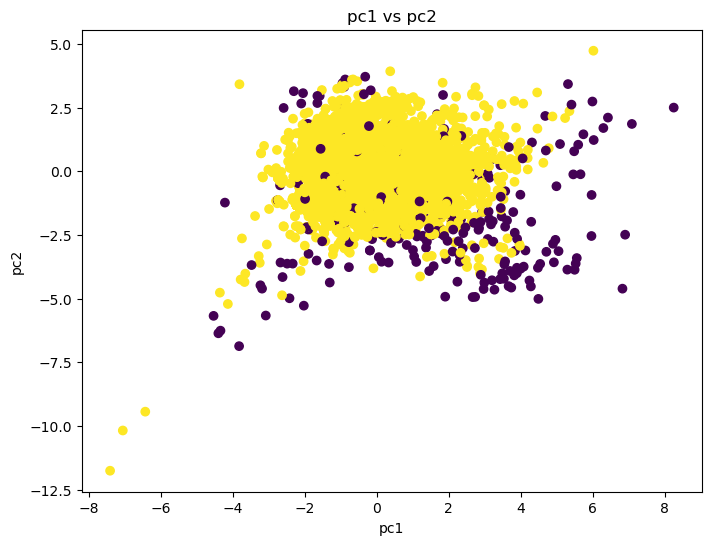

In [23]:
plt.figure(figsize = (8,6))
plt.scatter(x_pca[:,0],y=x_pca[:,1],c = labels)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pc1 vs pc2")

In [24]:
import numpy as np


In [26]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outliers = ",n_outliers)
print("normal: ",n_normal)

outliers =  270
normal:  6646
